# Exploratory Data Analysis of CS191W Dataset
Nachat Jatusripitak

In [ ]:
# Import required packages for data management and visualization
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns


plt.style.use('ggplot')

In [3]:
# Load dataset as CSV and print out the first few rows
df = pd.read_csv("dataset_1_pixels_grid_indices.csv")
print(df.head(10))

   row  col        date  pm25_today  u_wind_10m  v_wind_10m  dew_temp_2m  \
0    0    0  2022-12-27   13.625057    1.294254    0.312046    280.22186   
1    0    1  2022-12-27   12.278015    1.371728    0.206333    281.88910   
2    0    2  2022-12-27   11.339845    1.437077    0.102919    282.60867   
3    0    3  2022-12-27    9.915960    1.468449    0.009372    281.99050   
4    0    4  2022-12-27    8.805679    1.376245   -0.047940    281.41156   
5    0    5  2022-12-27    8.585770    1.284774   -0.104764    281.87958   
6    0    6  2022-12-27    8.825801    1.186792   -0.119717    282.12143   
7    0    7  2022-12-27   10.446621    1.080916   -0.066718    282.21982   
8    0    8  2022-12-27   12.289478    0.978458   -0.000943    283.37436   
9    0    9  2022-12-27   13.280171    0.824853    0.065097    284.76468   

     temp_2m  surf_pressure    precip_sum  frp  elevation  pm25_change  
0  287.84830      86948.180  8.523463e-07  0.0     1360.0    11.219316  
1  289.22437     

## Question 1: what does the dataset generally "look" like?

### Checking for missing values
There are no missing values in the dataset (by construction) - this was confirmed by calling .isnull().

In [4]:
print(df.isnull().sum())


row              0
col              0
date             0
pm25_today       0
u_wind_10m       0
v_wind_10m       0
dew_temp_2m      0
temp_2m          0
surf_pressure    0
precip_sum       0
frp              0
elevation        0
pm25_change      0
dtype: int64


### Computing summary statistics
**Features**

PM2.5 today
- Moderate average level (19.55 $\mu g/m^3$).
- Large range (~260 $\mu g/m^3$).
- Very high maximum (266.04 $\mu g/m^3$) but 75th percentile is low (23.4 $\mu g/m^3$) <br>
indicating that data is highly right-skewed with a heavy tail.

Wind (u-v components)
- Mean u-component: near zero, slightly eastward; v-component: positive, slightly northward.
- Standard deviations (~0.7 and 0.64) suggest gentle variability in wind direction/magnitude.

Dewpoint Temperature and Temperature
- Mostly warm, with temp_2m averaging ~296.86 K (~23.7°C) and peaking above 309 K (~36°C).

Surface Pressure
- Inverse relationship with elevation: Lower surface pressure values correspond to higher elevations.
- Narrow interquartile range (Q1–Q3): suggests most areas cluster around mid-elevation pressures.

Precipitation
- Highly skewed: mean is <0.01, median is 0.001 while max is 0.203.
- Most days have little to no rain but a few rainy days skew the data.

Fire Radiative Power (FRP)
- Extremely skewed: mean  is 1.67, median is 0, while max is ~13000.
- Most days have no fires (fires should be rare) but some days have intense fires.
- Strong right skew. May need transformation or thresholding (e.g., frp > 0).

Elevation
- Ranges from 9 to 1743 meters — terrain spans from lowlands to mountains.
- Might help model air dispersion or trap effects.

**Target**

Change in PM2.5 (target)
- Mean close to zero — makes sense for daily change.
- Std = 8.15, min = -213, max = 219 → shows sharp fluctuations on certain days (could be wind/fire/precip related).

In [5]:
print(df.drop(["row", "col"], axis=1).describe().drop(["count"]))

      pm25_today  u_wind_10m  v_wind_10m  dew_temp_2m     temp_2m  \
mean   19.554402    0.091469    0.383873   291.656450  296.855550   
std    18.848750    0.705141    0.640995     4.271280    3.198894   
min     4.267569   -4.000725   -3.179524   270.369700  279.223300   
25%     8.575294   -0.343777   -0.045244   288.775692  294.945040   
50%    11.992328    0.059128    0.367863   293.010200  296.965760   
75%    23.393567    0.537085    0.818380   294.959930  298.890530   
max   266.043150    4.283836    3.881630   299.439970  309.296020   

      surf_pressure  precip_sum           frp    elevation  pm25_change  
mean   93817.569670    0.004528      1.670447   646.885331     0.042865  
std     3126.278649    0.008462     41.575230   318.528501     8.156008  
min    83741.850000    0.000000      0.000000     9.000000  -213.133870  
25%    91445.840000    0.000005      0.000000   403.000000    -1.452106  
50%    93848.610000    0.000854      0.000000   638.000000     0.011303  
75%

### Computing correlation matrix
**Strong Relationships**

elevation and surf_pressure: -0.92

- Very strong negative correlation, as expected — higher elevation leads to lower surface pressure.

temp_2m and dew_temp_2m: 0.52

- Strong positive correlation — makes sense, since higher temperatures often correlate with more moisture in the air.

v_wind_10m and temp_2m: 0.4

- Moderate correlation — might indicate warm winds, possibly from specific directions.

**PM2.5-related Insights**

pm25_today and dew_temp_2m: -0.48

- Moderate negative correlation — higher moisture tends to suppress PM2.5.

pm25_today and precip_sum: -0.26

- Also a moderate negative correlation — precipitation likely helps wash PM2.5 out of the atmosphere.

pm25_today and temp_2m: 0.18

- Weak positive — warmer temps might be associated with stagnant air or fires, but the relationship isn't strong.

pm25_today and pm25_change: -0.2

- Slight negative correlation — possibly because large PM2.5 changes tend to occur when levels are low (and vice versa).

pm25_today and frp: 0.13

- Slight positive — not strong, but may still indicate that fire activity can contribute to elevated PM2.5 levels.

**pm25_change (Target Variable)**

No strong correlations with any predictors — this means PM2.5 change may depend on nonlinear interactions or <br>
localized spatiotemporal patterns that a model (like XGBoost) might capture better than simple correlations.

<Axes: >

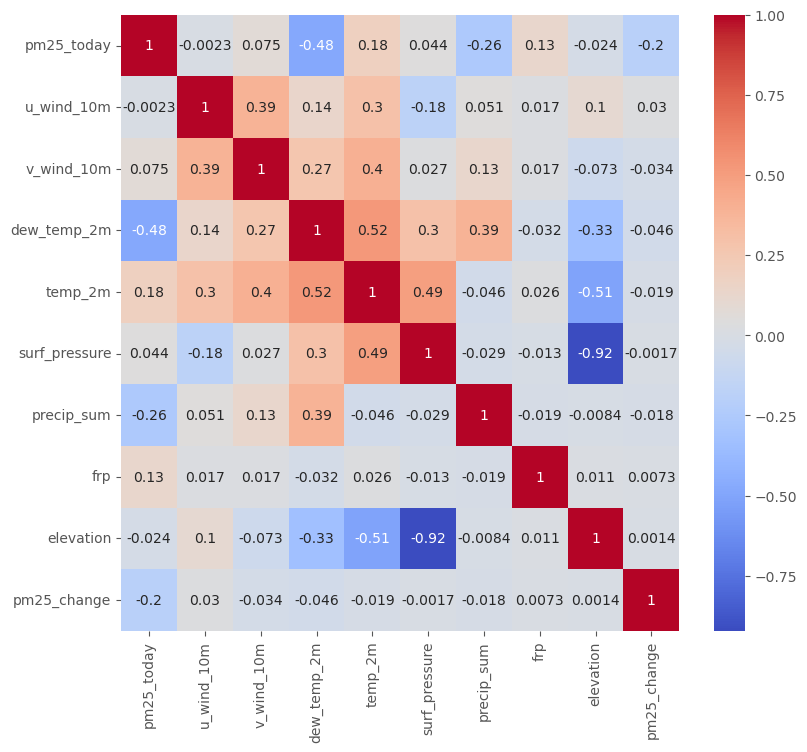

In [6]:
plt.figure(figsize=(9, 8))
sns.heatmap(df.drop(["row", "col", "date"], axis=1).corr(), annot=True, cmap='coolwarm')

## Question 2: How does PM2.5 change vary with current PM2.5 level?
- Scatterplot confirms negative correlation.
- While trend is linear, there is significant spread which indicates unexplained variability
- Conclusion: requires additional covariates to explain the variance.

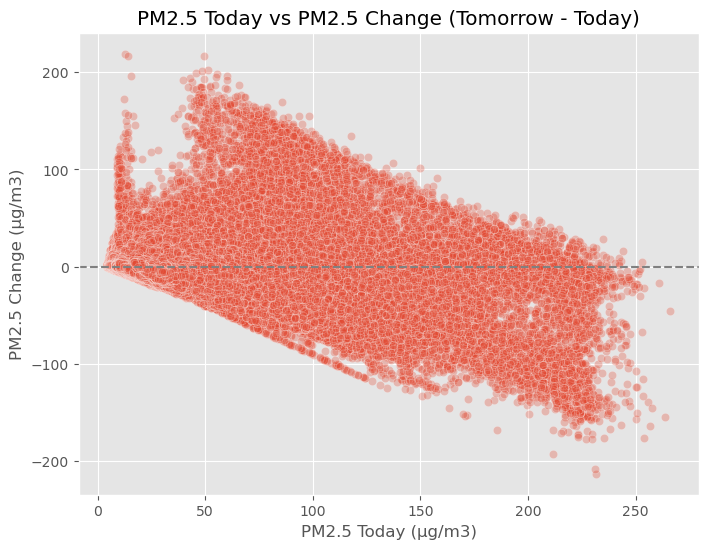

In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='pm25_today', y='pm25_change', data=df, alpha=0.3)
plt.title('PM2.5 Today vs PM2.5 Change (Tomorrow - Today)')
plt.xlabel('PM2.5 Today (μg/m3)')
plt.ylabel('PM2.5 Change (μg/m3)')
plt.axhline(0, color='gray', linestyle='--')
plt.show()


## Question 3: How does PM2.5 vary over space?

### Which places have the highest overall PM2.5 concentrations?
- Generally, the Northeastern areas of the images have the highest maximum PM2.5 concentrations.
- The lower parts, corresponding to lower Northern Thailand, have lower maximums.
- Extreme values can be found in the upper-right of the image, up to 250 $\mu g/m^3$.

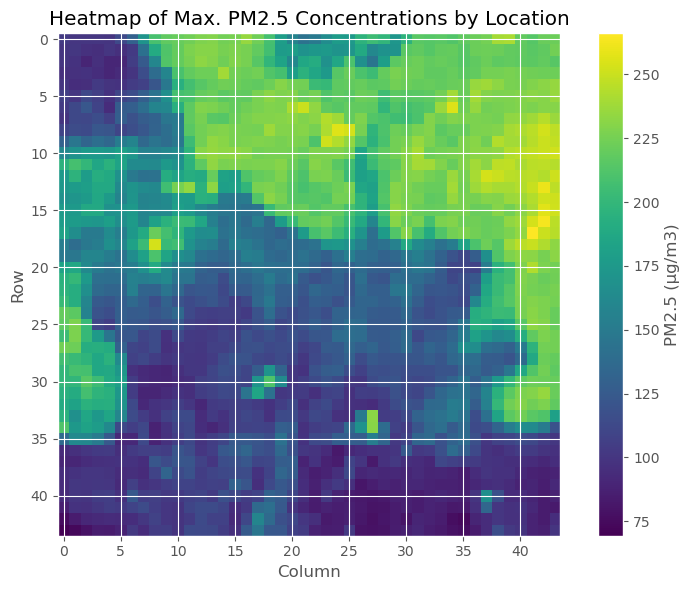

In [8]:
# Group data by grid location and take maximums
max_pm25_locs = (df.groupby(["row", "col"])["pm25_today"]
                 .max()
                 .sort_values(ascending=False))

# Convert data to heatmap
heatmap_df = max_pm25_locs.unstack(level='col')
data = heatmap_df.values  
fig, ax = plt.subplots(figsize=(8,6))

# origin='upper' makes row 0 draw at the top
im = ax.imshow(data, origin='upper', aspect='equal')

ax.set_xlabel('Column')
ax.set_ylabel('Row')
ax.set_title('Heatmap of Max. PM2.5 Concentrations by Location')

fig.colorbar(im, ax=ax, label='PM2.5 (μg/m3)')
plt.tight_layout()
plt.show()

### Which places have the highest mean PM2.5 concentrations?
- Central part of the image has highest mean PM2.5 concentrations.
- This area corresponds to urban places (Chiang Mai, Chiang Rai, etc.) and may <br>
indicate long-term accumulation of PM2.5.

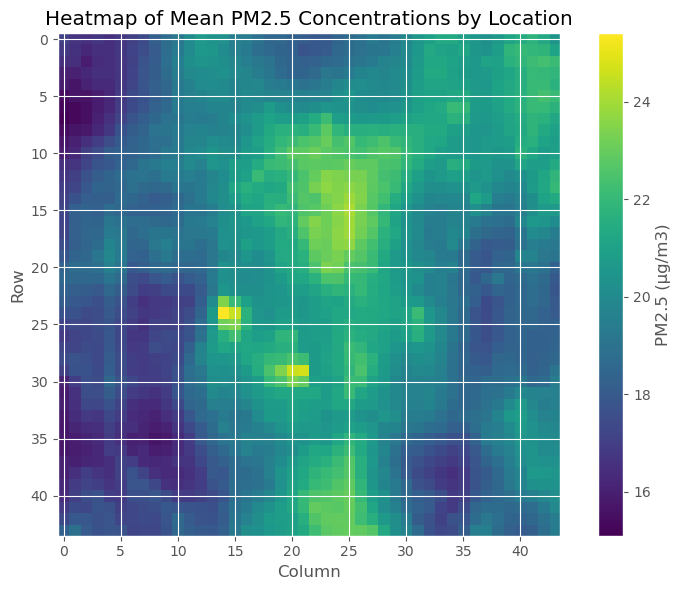

In [9]:
# Group data by grid location and take maximums
mean_pm25_locs = (df.groupby(["row", "col"])["pm25_today"]
                 .mean()
                 .sort_values(ascending=False))

# Convert data to heatmap
heatmap_df = mean_pm25_locs.unstack(level='col')
data = heatmap_df.values  
fig, ax = plt.subplots(figsize=(8,6))

# origin='upper' makes row 0 draw at the top
im = ax.imshow(data, origin='upper', aspect='equal')

ax.set_xlabel('Column')
ax.set_ylabel('Row')
ax.set_title('Heatmap of Mean PM2.5 Concentrations by Location')

fig.colorbar(im, ax=ax, label='PM2.5 (μg/m3)')
plt.tight_layout()
plt.show()

## Question 4: How does PM2.5 vary over time?

### How does PM2.5 vary seasonally?
- Low PM2.5 levels during June-September
- Levels start to increase during October-February
- Peak levels in March
- Levels decline during April-May

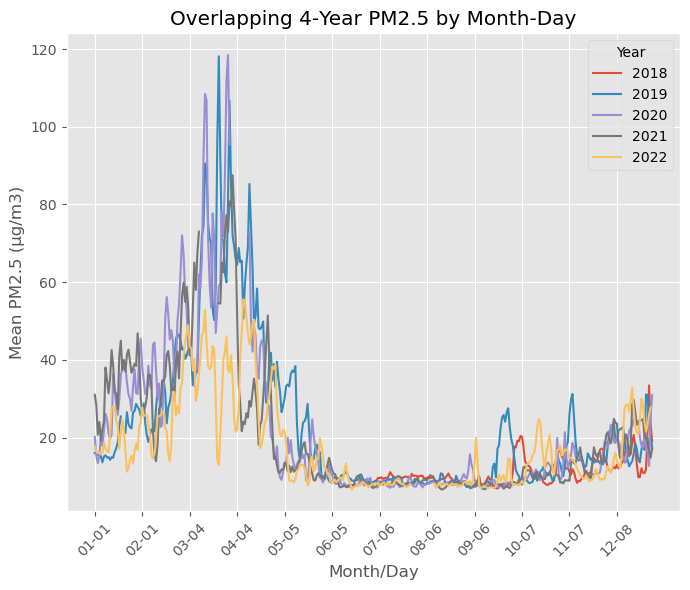

In [12]:
# Copy dataset to avoid changing original
df_copy = df.copy()

# Create year and month-day labels
df_copy['date'] = pd.to_datetime(df_copy['date'], format='%Y-%m-%d')
df_copy['year'] = df_copy['date'].dt.year
df_copy['month'] = df_copy['date'].dt.month
df_copy['md']   = df_copy['date'].dt.strftime('%m-%d')

# Pivot so each column is a year, indexed by 'MM-DD'
pivot = df_copy.pivot_table(
    index='md',
    columns='year',
    values='pm25_today',
    aggfunc='mean'
)

# Force calendar order for all month-days (using a dummy non-leap year)
md_range = pd.date_range('2021-01-01','2021-12-31').strftime('%m-%d')
pivot = pivot.reindex(md_range, fill_value=np.nan)

# Plot overlapping time series
plt.figure(figsize=(7,6))
for yr in pivot.columns:
    plt.plot(pivot.index, pivot[yr], label=str(yr))

plt.xticks(pivot.index[::31], rotation=45)
plt.xlabel('Month/Day')
plt.ylabel('Mean PM2.5 (μg/m3)')
plt.title('Overlapping 4‑Year PM2.5 by Month‑Day')
plt.legend(title='Year')
plt.tight_layout()
plt.show()


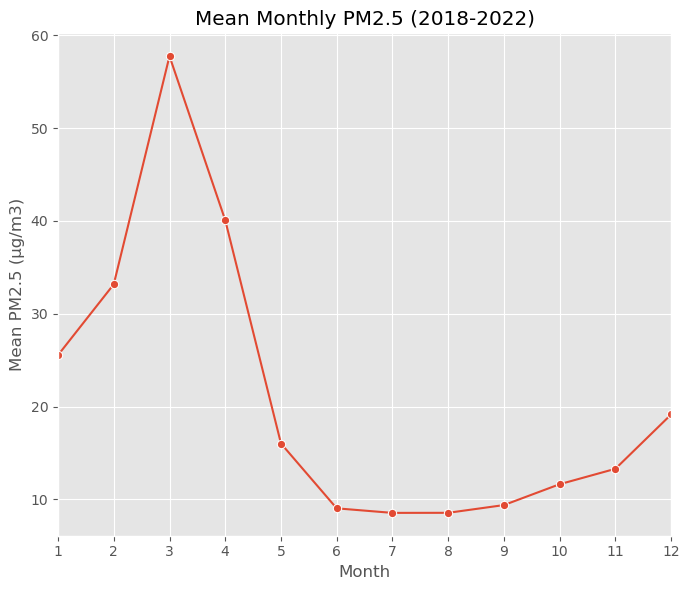

In [13]:
monthly_avg_pm25 = df_copy.groupby("month")["pm25_today"].mean()

df_month = monthly_avg_pm25.reset_index()
df_month.columns = ['month', 'value']

plt.figure(figsize=(7,6))
sns.lineplot(
    data=df_month,
    x='month',
    y='value',
    marker='o'
)
plt.xticks(range(1,13))     
plt.xlim(1,12)
plt.xlabel('Month')
plt.ylabel('Mean PM2.5 (μg/m3)')
plt.title('Mean Monthly PM2.5 (2018-2022)')
plt.tight_layout()
plt.show()


2020-07-22 0.6086714946546885
2021-01-03 17.09663489179874
2019-07-31 1.0771147275571908
2019-08-20 0.7551744686088893
2021-02-21 56.403835541082685
2019-04-05 187.71070400868703
2020-12-11 2.9859131108051264
2019-05-29 4.0055941382610545
2021-01-09 41.06018110130575
2021-05-03 1.9274838828261425
2018-11-25 6.926264039214452
2021-01-01 48.83940057700639
2019-07-25 0.6397997204353684
2022-02-16 50.22989212606686
2022-01-12 13.885101624812084
2022-12-18 20.268640933789595
2020-10-10 0.8411762375005706
2019-01-15 28.826239878181493
2021-09-11 0.9539056208177465
2020-04-19 265.6540768294209
2019-09-30 44.02763969122202
2021-05-29 1.924886909165833
2021-07-30 0.6562784671437407
2018-10-07 8.292471264979076
2021-01-10 36.43851737573281
2022-10-11 7.902357860419691
2022-01-22 8.771315918696303
2019-01-18 21.215427794859462
2020-09-16 0.661678851652126
2022-07-03 0.9758233805982419
2019-03-26 534.0274191071949
2021-01-13 80.77839544071759
2020-07-23 1.3405541048996987
2022-07-24 0.618726117117